<a href="https://colab.research.google.com/github/Ashritakhokle/aiml/blob/main/sales_forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Actual**

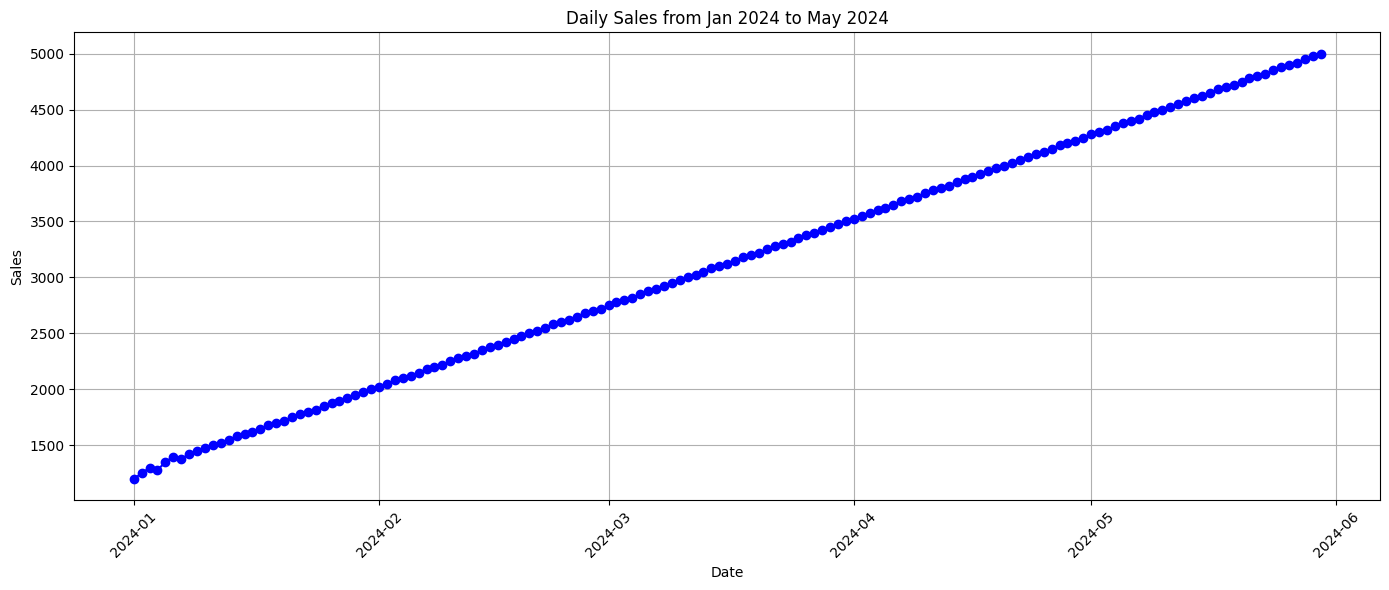

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "date": pd.date_range(start="2024-01-01", periods=151, freq="D"),
    "sales": [
        1200,1250,1300,1280,1350,1400,1380,1420,1450,1480,
        1500,1520,1550,1580,1600,1620,1650,1680,1700,1720,
        1750,1780,1800,1820,1850,1880,1900,1920,1950,1980,
        2000,2020,2050,2080,2100,2120,2150,2180,2200,2220,
        2250,2280,2300,2320,2350,2380,2400,2420,2450,2480,
        2500,2520,2550,2580,2600,2620,2650,2680,2700,2720,
        2750,2780,2800,2820,2850,2880,2900,2920,2950,2980,
        3000,3020,3050,3080,3100,3120,3150,3180,3200,3220,
        3250,3280,3300,3320,3350,3380,3400,3420,3450,3480,
        3500,3520,3550,3580,3600,3620,3650,3680,3700,3720,
        3750,3780,3800,3820,3850,3880,3900,3920,3950,3980,
        4000,4020,4050,4080,4100,4120,4150,4180,4200,4220,
        4250,4280,4300,4320,4350,4380,4400,4420,4450,4480,
        4500,4520,4550,4580,4600,4620,4650,4680,4700,4720,
        4750,4780,4800,4820,4850,4880,4900,4920,4950,4980,5000
    ]
}

df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(14,6))
plt.plot(df['date'], df['sales'], marker='o', linestyle='-', color='blue')
plt.title("Daily Sales from Jan 2024 to May 2024")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


**Trainred**

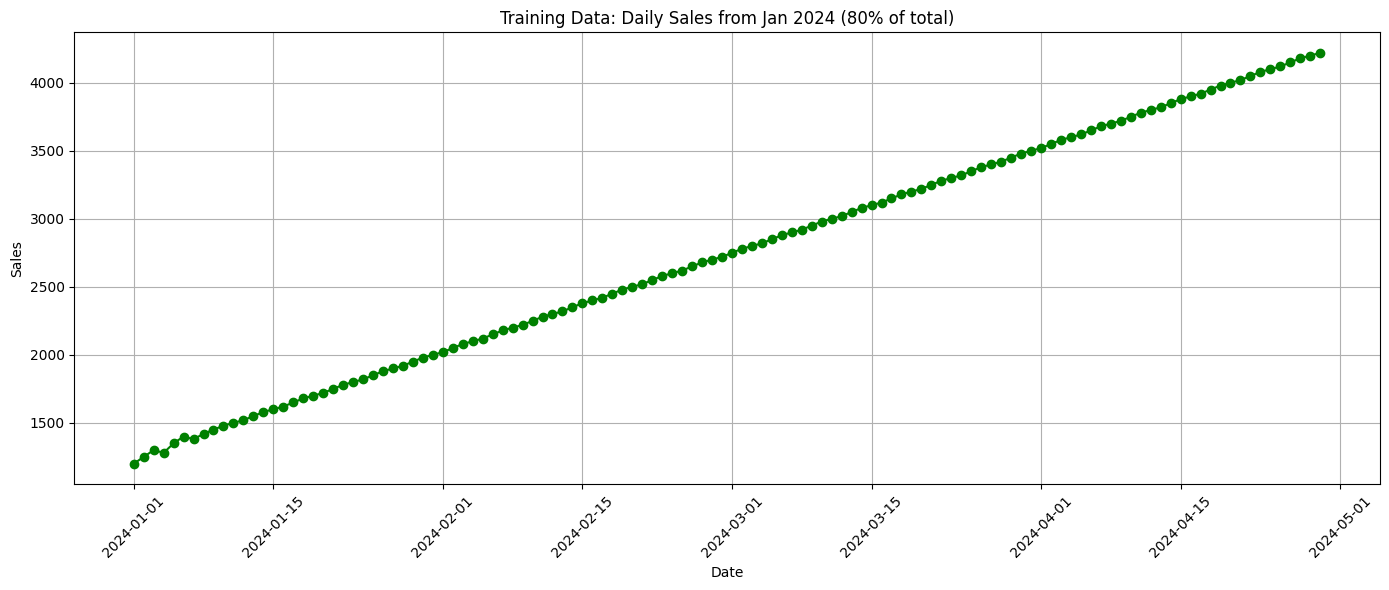

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Data
data = {
    "date": pd.date_range(start="2024-01-01", periods=151, freq="D"),
    "sales": [
        1200,1250,1300,1280,1350,1400,1380,1420,1450,1480,
        1500,1520,1550,1580,1600,1620,1650,1680,1700,1720,
        1750,1780,1800,1820,1850,1880,1900,1920,1950,1980,
        2000,2020,2050,2080,2100,2120,2150,2180,2200,2220,
        2250,2280,2300,2320,2350,2380,2400,2420,2450,2480,
        2500,2520,2550,2580,2600,2620,2650,2680,2700,2720,
        2750,2780,2800,2820,2850,2880,2900,2920,2950,2980,
        3000,3020,3050,3080,3100,3120,3150,3180,3200,3220,
        3250,3280,3300,3320,3350,3380,3400,3420,3450,3480,
        3500,3520,3550,3580,3600,3620,3650,3680,3700,3720,
        3750,3780,3800,3820,3850,3880,3900,3920,3950,3980,
        4000,4020,4050,4080,4100,4120,4150,4180,4200,4220,
        4250,4280,4300,4320,4350,4380,4400,4420,4450,4480,
        4500,4520,4550,4580,4600,4620,4650,4680,4700,4720,
        4750,4780,4800,4820,4850,4880,4900,4920,4950,4980,5000
    ]
}

df = pd.DataFrame(data)

# Split into train (80%)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]

# Plot train data
plt.figure(figsize=(14,6))
plt.plot(train_df['date'], train_df['sales'], marker='o', linestyle='-', color='green')
plt.title("Training Data: Daily Sales from Jan 2024 (80% of total)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()


**Predicted**

/tmp/ipython-input-3949174709.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['predicted'] = model.predict(train_df[['day']])
/tmp/ipython-input-3949174709.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted'] = model.predict(test_df[['day']])


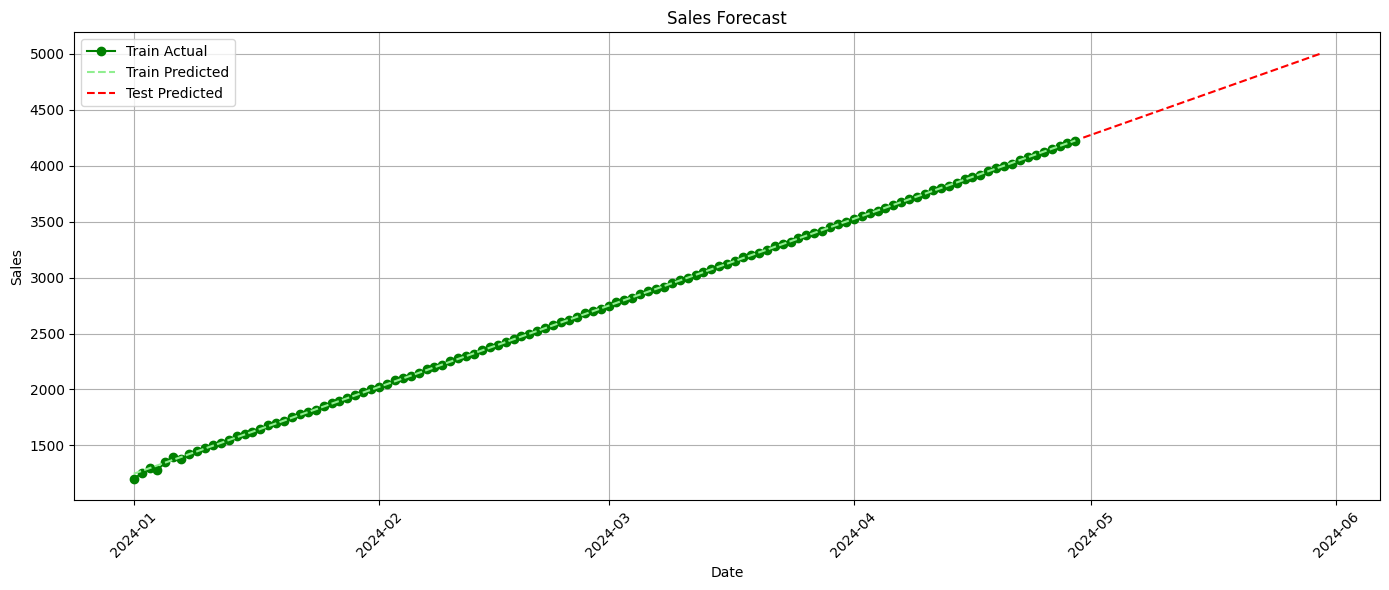

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

# Prepare data
df['day'] = np.arange(len(df))  # numeric day for regression
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

# Train linear regression
model = LinearRegression()
model.fit(train_df[['day']], train_df['sales'])

# Predict for train and test
train_df['predicted'] = model.predict(train_df[['day']])
test_df['predicted'] = model.predict(test_df[['day']])

# Plot
plt.figure(figsize=(14,6))
plt.plot(train_df['date'], train_df['sales'], marker='o', linestyle='-', label='Train Actual', color='green')
plt.plot(train_df['date'], train_df['predicted'], linestyle='--', label='Train Predicted', color='lightgreen')
plt.plot(test_df['date'], test_df['predicted'], linestyle='--', label='Test Predicted', color='red')
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
